<a href="https://colab.research.google.com/github/prasa129/Math/blob/main/LU_Factorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LU Factorization



09-11-2025


Quick implementation of LU factorization with partial and full pivoting to solve systems of the from $Ax = b$, assessment of numerical stability using Hilbert matrix, and comparison to Numpy's solver, following Prof. Peter Olver's (UMN) notes.

$\textbf{LU Factorization:}$

LU factorization decomposes a square matrix $A$ into a lower unitriangular $L$ and upper triangular $U$:

$$
A = LU
$$

by performing Gaussian elimination and recording the additive inverse of multipliers used to zero out column entries below $A$'s pivots in $L$. The reduced echelon form of $A$ becomes $U$. Algorithmically,

Let $A \in \mathbb{R}^{n \times n}$. Initialize $L$ as $I_{n}$ and $U$ as a copy of A. For $k=1...n$:

1. Compute the $k$-th row of U:

$$
U_{k,j} = A_{k,j} - \sum_{s=1}^{k-1}L_{k,s}U_{s,j} \text{ }(j=k...n)
$$

2. Compute the $k$-th column of L, below the pivot:

$$
L_{i,k} = \frac{1}{U_{k,k}}(A_{i,k} - \sum_{s=1}^{k-1}L_{i,s}U_{s,k}) \text{ }(i=k+1...n)
$$

If $U_{k,k}=0$ at any point, raise error.

Partial pivoting is a procedure to address the numerical fragility of basic LU factorization, and works by swapping the current row with a lower row containing the largest (by absolute value) pivot in the column. Where $P$ is a permutation matrix for rows,

$$
PA = LU
$$

Algorithmically, for $k=1...n$:

1. Select pivot row $i^{*}=\arg \max_{i \in \{k...n \} }|U_{i,k}|$

2. Swap rows $k$ and $i^{*}$ in $U$ and $P$, swap the first $k-1$ entries of those corresponding rows in $L$

3. Perform elimination. For $i=k+1...n$:

\begin{align*}
L_{i,k} &= \frac{U_{i,k}}{U_{k,k}} \\
U_{i,k:n} \leftarrow & \text{ }U_{i,k:n} - L_{i,k}U_{k,k:n}
\end{align*}

Full pivoting swaps rows and columns. Specifically, the procedure is to search the entire submatrix to identify the maximum entry and swap it and its column into position. For $Q$ the column permutation matrix,

$$
PAQ = LU
$$

Algorithmically, for $k=1...n$:

1. Select the pivot at $(i^{*}, j^{*}) = \arg \max_{i,j \ge k}|U_{i,j}|$

2. Swap rows $k \leftrightarrow i^{*}$ in $U,P$, and columns $1...k-1$ of $L$

3. Swap columns $k \leftrightarrow j^{*}$ in $U,Q$

4. Perform elimination. For $r = k+1,...,n$

\begin{align*}
L_{r,k} &= \frac{U_{r,k}}{U_{k,k}} \\
U_{r,k:n} \leftarrow & \text{ }U_{r,k:n} - L_{r,k}U_{k,k:n}
\end{align*}

With $L,U$, and possibly $P,Q$ computed, a general linear system $Ax=b$ can be solved as follows:

- Basic: $A=LU$, solve $Ly=b$ using forward substitution, and then $Ux=y$ using backward substitution.

- Partial: $PA = LU$, solve $Ly=Pb$ and $Ux=y$.

- Full: $PAQ = LU$. Let $y=Q'x$, solve $Ly=Pb$, $Uz=y$, and finally $x=Qz$.

Full pivoting is slower on account of the column swaps. I implement the methods and solvers below:



In [1]:
#Standard imports
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Import more precise timer
from time import perf_counter

#Set print output float precision
np.set_printoptions(precision=4, suppress=True)


"""
LU Factorization:
  - lu_basic_stats: basic LU factorization
  - lu_partial_stats: partial pivoting
  - lu_full_stats: full pivoting
"""
def lu_basic_stats(A):
    """
    Perform LU factorization. No interchanging of rows or columns.
    Args:
      A: np.ndarray, the matrix (n x n) to decompose
    Returns:
      L: np.ndarray, lower unitriangular matrix
      U: np.ndarray, upper triangular matrix
      stats: dict, growth trace and growth factor
    Compute error measures.
    """

    #Check for valid input
    try:
      assert(type(A)==np.ndarray)
      assert(A.ndim==2)
    except AssertionError:
      raise ValueError("Invalid input")

    #Check for square matrix
    if A.shape[0] != A.shape[1]:
      raise ValueError("Input matrix is not square. Use QR/SVD.")

    #Copy input matrix
    A = A.astype(float).copy()
    n = A.shape[0]

    #Initialize L as I_nxn
    L = np.eye(n)

    #Initialize U as 0_nxn
    U = np.zeros_like(A)

    #Set maximum element wise of A
    maxA = np.max(np.abs(A))

    #Initialize list for growth factor
    growth_trace = []

    #For column k=1...n of A
    for k in range(n):

        #Form k-th row of U and update pivot
        U[k, k:] = A[k, k:] - L[k, :k] @ U[:k, k:]
        pivot = U[k, k]

        #Exit if pivot if 0
        if abs(pivot) < 1e-15:
            raise np.linalg.LinAlgError("Zero pivot in LU without pivoting")

        #Form k-th column of L
        for i in range(k+1, n):
            L[i, k] = (A[i, k] - L[i, :k] @ U[:k, k]) / pivot

        #Update per step growth trace
        growth_trace.append(float(np.max(np.abs(U))) / (maxA + 1e-300))

    #Combine error/performance measures in dictionary
    stats = {"growth_trace": growth_trace, "growth_factor": max(growth_trace) if growth_trace else 1.0, "maxA": maxA}

    #Return LU decomp and stability stats
    return L, U, stats

def lu_partial_stats(A):
    """
    Perform LU factorization with partial pivoting.
    Args:
      A: np.ndarray, the matrix (n x n) to decompose
    Returns:
      P: np.ndarray, permutation matrix
      L: np.ndarray, lower unitriangular matrix
      U: np.ndarray, upper triangular matrix
      stats: dict, growth trace and growth factor
    Permit row swaps.
    """
    #Check for valid input
    try:
      assert(type(A)==np.ndarray)
      assert(A.ndim==2)
    except AssertionError:
      raise ValueError("Invalid input")

    #Check for square matrix
    if A.shape[0] != A.shape[1]:
      raise ValueError("Input matrix is not square. Use QR/SVD.")

    #Copy input matrix, initialize U
    A = A.astype(float).copy()
    n = A.shape[0]
    U = A.copy()

    #Initialize permutation matrix as I_n
    P = np.eye(n)

    #Initialize L as 0_nxn
    L = np.zeros_like(A)

    #Set initial maximum element of A
    maxA = np.max(np.abs(A))

    #Empty list for growth factors
    growth_trace = []

    #For column k = 1...n
    for k in range(n):

        #Identify pivot row for column k
        idx = k + np.argmax(np.abs(U[k:, k]))

        #Exit if pivot is 0
        if abs(U[idx, k]) < 1e-15:
            raise np.linalg.LinAlgError("Matrix is singular to working precision (partial)")

        #Perform row swap if index of row containing max isn't k
        if idx != k:

            #Swap rows in U
            U[[k, idx], :] = U[[idx, k], :]

            #Record the same swap in permutation matrix P
            P[[k, idx], :] = P[[idx, k], :]

            #Swap already built part of L
            L[[k, idx], :k] = L[[idx, k], :k]

        #Ensure L's is unitriangular
        L[k, k] = 1.0

        #Gaussian elimination step
        for i in range(k+1, n):

            #Compute multiplier l_ik to zero entry under pivot
            L[i, k] = U[i, k] / U[k, k]

            #Update row in U
            U[i, k:] = U[i, k:] - L[i, k] * U[k, k:]

            #Set entry of U to 0.0 explicitly to avoid round off error
            U[i, k] = 0.0

        #Track per step element growth
        growth_trace.append(float(np.max(np.abs(U))) / (maxA + 1e-300))

    #Store growth trace, overall element growth, largest element in original matrix
    stats = {"growth_trace": growth_trace, "growth_factor": max(growth_trace) if growth_trace else 1.0, "maxA": maxA}

    #Return permutation matrix, lower unitriangular and upper triangular decomp, and stability stats
    return P, L, U, stats

#LU factorization with full pivoting
def lu_full_stats(A):
    """
    Perform LU factorization with full pivoting.
    Args:
      A: np.ndarray, the matrix (n x n) to decompose
    Returns:
      P: np.ndarray, permutation matrix
      Q: np.ndarray, column permutation matrix
      L: np.ndarray, lower unitriangular matrix
      U: np.ndarray, upper triangular matrix
      stats: dict, growth trace and growth factor
    Interchange columns and rows.
    """
    #Check for valid inputs
    try:
      assert(type(A)==np.ndarray)
      assert(A.ndim==2)
    except AssertionError:
      raise ValueError("Invalid input")

    #Check for square matrix
    if A.shape[0] != A.shape[1]:
      raise ValueError("Input matrix is not square. Use QR/SVD.")

    #Copy input matrix, initialize U
    A = A.astype(float).copy()
    n = A.shape[0]
    U = A.copy()

    #Initialize L, P, Q as I_n
    L = np.zeros_like(A)
    P = np.eye(n)
    Q = np.eye(n)

    #Set maximum element of A
    maxA = np.max(np.abs(A))

    #Empty list for growth factors
    growth_trace = []

    #For column k=1...n in A
    for k in range(n):

        """
        Pivot search - find largest (magnitude) entry in submatrix
        """
        #Take absolute value of active trailing submatrix
        sub = np.abs(U[k:, k:])

        #Index of first max in sub relative to sub array
        i_rel, j_rel = np.unravel_index(np.argmax(sub), sub.shape)

        #Shift relative indices back to global row/col indices
        i = k + i_rel
        j = k + j_rel

        #Exit if pivot is 0
        if abs(U[i, j]) < 1e-15:
            raise np.linalg.LinAlgError("Matrix is singular to working precision (full)")

        #Swap rows, bring chosen pivot row i to active row k
        if i != k:
            #Swap rows in working matrix U
            U[[k, i], :] = U[[i, k], :]

            #Accumulate same row swap in P
            P[[k, i], :] = P[[i, k], :]

            #Update computed part of L
            L[[k, i], :k] = L[[i, k], :k]

        #Swap columns, bring chosen pivot col j into active col k
        if j != k:

            #Swap columns k and j of U
            U[:, [k, j]] = U[:, [j, k]]

            #Record col swap in perm matrix Q
            Q[:, [k, j]] = Q[:, [j, k]]

        #Enforce L unitriangular
        L[k, k] = 1.0

        #Gaussian elimination
        for r in range(k+1, n):

            #Compute multiplier l_rk
            L[r, k] = U[r, k] / U[k, k]

            #Row update U and force exact zero
            U[r, k:] = U[r, k:] - L[r, k] * U[k, k:]
            U[r, k] = 0.0

        #Track per step element growth
        growth_trace.append(float(np.max(np.abs(U))) / (maxA + 1e-300))

    #Summarize stability stats (element growth, overall growth factor, largest abs. element of initial matrix)
    stats = {"growth_trace": growth_trace, "growth_factor": max(growth_trace) if growth_trace else 1.0, "maxA": maxA}

    #Return row and column permutation matrices, LU factorization, stabitlity stats
    return P, Q, L, U, stats

"""
Forward and Backwards Substitution:
"""
def forward_substitution(L, b):
    """
    Solve system using forward substitution.
    Args:
      L: np.ndarray, lower unitriangular matrix
      b: np.ndarray, right-hand side vector
    Returns:
      y: np.ndarray, solution vector
    Ly = b, solve for y.
    """
    #Init solution vectors as nx1 zeros
    n = L.shape[0]
    y = np.zeros_like(b, dtype=float)

    #Solve system one row at a time
    for i in range(n):

        #i'th equation L_i,0*y0 + ... + L_i,i*yi
        y[i] = b[i] - L[i, :i] @ y[:i]

        #Skip division when L_ii = 1
        if abs(L[i, i] - 1.0) > 1e-15:

            #Divide by L_ii
            y[i] /= L[i, i]

    #Return solution vector
    return y

def back_substitution(U, y):
    """
    Solve system using back substitution.
    Args:
      U: np.ndarray, upper triangular matrix
      y: np.ndarray, right-hand side vector
    Returns:
      x: np.ndarray, solution vector
    Ux = y, solve for x.
    """
    #Init solution vectors as n x 1 zeros
    n = U.shape[0]
    x = np.zeros_like(y, dtype=float)

    #Solve system by row, from last to first
    for i in range(n-1, -1, -1):

        #denominator is pivot of row i
        denom = U[i, i]

        #Exit if pivot is 0
        if abs(denom) < 1e-15:
            raise np.linalg.LinAlgError("Singular U in back substitution")

        #Rearrange row i of Ux=y. Subtract trailing sum, divide by pivot.
        x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / denom
    return x

"""
Solve Functions:
"""
#Basic LU
def lu_solve_basic(L, U, b):
    """
    Solve Ax=b using LU factorization.
    Args:
      L: np.ndarray, lower unitriangular matrix
      U: np.ndarray, upper triangular matrix
      b: np.ndarray, right-hand side vector
    Returns:
      x: np.ndarray, solution vector
    """
    #Perform forward and back substitution
    y = forward_substitution(L, b)
    x = back_substitution(U, y)
    return x

#Partial pivoting
def lu_solve_partial(P, L, U, b):
    """
    Solve Ax=b using LU factorization with partial pivoting.
    Args:
      P: np.ndarray, permutation matrix
      L: np.ndarray, lower unitriangular matrix
      U: np.ndarray, upper triangular matrix
      b: np.ndarray, right-hand side vector
    Returns:
      x: np.ndarray, solution vector
    """
    #Permute RHS vector
    pb = P @ b

    #Perform forward and back substitution
    y = forward_substitution(L, pb)
    x = back_substitution(U, y)
    return x

#Full pivoting
def lu_solve_full(P, Q, L, U, b):
    """
    Solve Ax=b using LU factorization with full pivoting
    Args:
      P: np.ndarray, permutation matrix
      Q: np.ndarray, column permutation matrix
      L: np.ndarray, lower unitriangular matrix
      U: np.ndarray, upper triangular matrix
      b: np.ndarray, right-hand side vector
    Returns:
      x: np.ndarray, solution vector
    """
    #Permute RHS vector
    pb = P @ b

    #Perform forward and back substitution
    z = forward_substitution(L, pb)
    y = back_substitution(U, z)

    #Permute solution vector and return
    x = Q @ y
    return x

Hilbert matrices are ill-conditioned. I test the factorization methods and associated solvers on $H_{n}$ of increasing dimension $n=3...15$:

$$H_n=\left(\frac{1}{i+j-1}\right)_{i,j} \text{ for } i,j=1...n$$

In [2]:
"""
Test matrix and error diagnostics functions
"""
#Generate Hilbert matrix
def hilbert(n):
    """
    Generate the Hilbert matrix of size n x n.
    Args:
      n: int, size of Hilbert matrix
    Returns:
      Hn: np.ndarray, Hilbert matrix of size n x n
    H_ij = 1 / (i + j - 1)
    """
    #Generate row and column indices
    i = np.arange(1, n+1)[:, None]
    j = np.arange(1, n+1)[None, :]

    #Vectorized construction
    Hn = 1.0 / (i + j - 1.0)
    return Hn

hilbert(5)

array([[1.    , 0.5   , 0.3333, 0.25  , 0.2   ],
       [0.5   , 0.3333, 0.25  , 0.2   , 0.1667],
       [0.3333, 0.25  , 0.2   , 0.1667, 0.1429],
       [0.25  , 0.2   , 0.1667, 0.1429, 0.125 ],
       [0.2   , 0.1667, 0.1429, 0.125 , 0.1111]])

$\textbf{Performance Measures and Error Tracking:}$

For $\hat{x}$ the estimated solution to the system $Ax=b$, I examine several error measures:

- Per-step growth trace, computed after each elimination step $k$:

$$
\rho_{k} = \text{max} \frac{|U^{(k)} |}{\text{max}|A|}
$$

- Growth factor:

$$
\rho = \text{max}_{k} \rho_{k}
$$

- Relative forward error:

$$
\frac{||\hat{x} - x||}{||x||}
$$

- Raw residual:

$$
|| A \hat{x} - b ||
$$

- Relative residual:

$$
\frac{|| A \hat{x} - b ||}{||b||}
$$

- Scaled backward error:

$$
\frac{|| A \hat{x} - b || }{||A||\text{ }||\hat{x}|| + ||b||}
$$

- Componentwise backward error

$$
\eta_{c} = \text{max}_{i} \frac{|r_{i}|}{(|A||\hat{x}| + |b|)_{i}}, \text{ } r= A\hat{x}-b
$$

In [3]:
#Utility function to compute error measures and performance stats
def errors_and_stats(A, x_true, method="numpy"):
    """
    Compute error measures and performance statistics for a linear system
    of the form Ax = b for different solvers. Time execution.
    Args:
      A: np.ndarray, the coefficient matrix (n x n)
      x_true: np.ndarray, the true solution (n x 1) to Ax=b
      method: str, one of "basic", "partial", "full", "numpy"
    Returns:
      record: dict, error measures and performance stats
    Function computes RHS b. Time execution using perf_counter for accuracy.
    Error measures:
      - forward error
      - relative forward error
      - relative residual
      - residual norm
      - scaled backward error
      - componentwise backward error
      - growth factor
    """
    #Compute RHS of linear system, b
    b = A @ x_true

    #Start timing
    t0 = perf_counter()

    #Call appropriate solver based on passed in method
    try:

        #Basic LU
        if method == "basic":
            L, U, stats = lu_basic_stats(A)
            xhat = lu_solve_basic(L, U, b)
            growth = stats["growth_factor"]

        #LU with partial pivoting
        elif method == "partial":
            P, L, U, stats = lu_partial_stats(A)
            xhat = lu_solve_partial(P, L, U, b)
            growth = stats["growth_factor"]

        #LU with full pivoting
        elif method == "full":
            P, Q, L, U, stats = lu_full_stats(A)
            xhat = lu_solve_full(P, Q, L, U, b)
            growth = stats["growth_factor"]

        #Numpy's solver
        elif method == "numpy":
            xhat = np.linalg.solve(A, b)
            growth = np.nan

        #Raise error if another method given
        else:
            raise ValueError("unknown method")

        #Barring unknown method, set status as ok
        status = "ok"

    #If method not found, populate estimated solution with nans
    except Exception as e:
        xhat = np.full_like(x_true, np.nan, dtype=float)
        growth = np.nan
        status = f"fail: {type(e).__name__}"

    #Measure time elapsed
    t1 = perf_counter() - t0

    #If solver fails
    if np.any(np.isnan(xhat)):

        #Set error measures as inf
        fwd = np.inf; resid = np.inf; comp_back = np.inf
        rel_fwd = np.inf; rel_resid = np.inf

    #Otherwise, compute error measures
    else:
        #Forward error
        fwd = np.linalg.norm(xhat - x_true)

        #Relative forward error
        rel_fwd = fwd / (np.linalg.norm(x_true) + 1e-300)

        #L2 norm of residual
        r = A @ xhat - b
        resid = np.linalg.norm(r)

        #Relative residual
        rel_resid = np.linalg.norm(r) / (np.linalg.norm(b) + 1e-300)

        #Scaled backward error
        comp_back = np.linalg.norm(r) / (np.linalg.norm(A) * np.linalg.norm(xhat) + np.linalg.norm(b) + 1e-300)

        #Component wise backward error
        denom = np.abs(A) @ np.abs(xhat) + np.abs(b) + 1e-300
        eta = np.max(np.abs(r) / denom)

    #return dict with results, will be used as 1 row of DF
    record = {"method": method,
              "status": status,
              "time_s": t1,
              "forward_err": fwd,
              "rel_forward_err": rel_fwd,
              "rel_residual": rel_resid,
              "residual_norm": resid,
              "scaled_backward_err": comp_back,
              "growth_factor": growth
              }
    return record


#Test I_5x = 1_5 (all errors 0)
errors_and_stats(np.identity(5), np.ones(5), method="partial")

{'method': 'partial',
 'status': 'ok',
 'time_s': 0.0005195880003157072,
 'forward_err': np.float64(0.0),
 'rel_forward_err': np.float64(0.0),
 'rel_residual': np.float64(0.0),
 'residual_norm': np.float64(0.0),
 'scaled_backward_err': np.float64(0.0),
 'growth_factor': np.float64(1.0)}

Finally, I run the experiment. For each method and for $n=3...19$, I generate Hilbert matrices, solve the system $H_{n}1_{n} = b$, where $b$ is the vector of $H_{n}$'s row sums. The true solution is $1_{n}$ to draw out minor differences in numerical stability.

Hilbert family:


,method,status,time_s,forward_err,rel_forward_err,rel_residual,residual_norm,scaled_backward_err,growth_factor,n,label
0,basic,ok,0.000287,2.830176e-14,1.634003e-14,4.893019e-17,1.110223e-16,2.353432e-17,1.0,3,Basic
1,partial,ok,0.000286,1.093443e-15,6.312995e-16,0.000000e+00,0.000000e+00,0.000000e+00,1.0,3,Partial
2,full,ok,0.000343,1.419176e-14,8.193616e-15,9.786038e-17,2.220446e-16,4.706865e-17,1.0,3,Full
3,numpy,ok,0.000124,1.389554e-14,8.022594e-15,0.000000e+00,0.000000e+00,0.000000e+00,NaN,3,NumPy
4,basic,ok,0.002346,6.929784e-15,3.464892e-15,4.063019e-17,1.110223e-16,1.930159e-17,1.0,4,Basic
5,partial,ok,0.000320,3.023827e-13,1.511914e-13,4.063019e-17,1.110223e-16,1.930159e-17,1.0,4,Partial
6,full,ok,0.000444,3.820439e-13,1.910219e-13,0.000000e+00,0.000000e+00,0.000000e+00,1.0,4,Full
7,numpy,ok,0.000066,8.274819e-14,4.137410e-14,0.000000e+00,0.000000e+00,0.000000e+00,NaN,4,NumPy
8,basic,ok,0.000267,2.997602e-11,1.340568e-11,1.659319e-16,5.207408e-16,7.803354e-17,1.0,5,Basic
9,partial,ok,0.003641,8.289747e-13,3.707287e-13,1.621169e-16,5.087681e-16,7.623943e-17,1.0,5,Partial


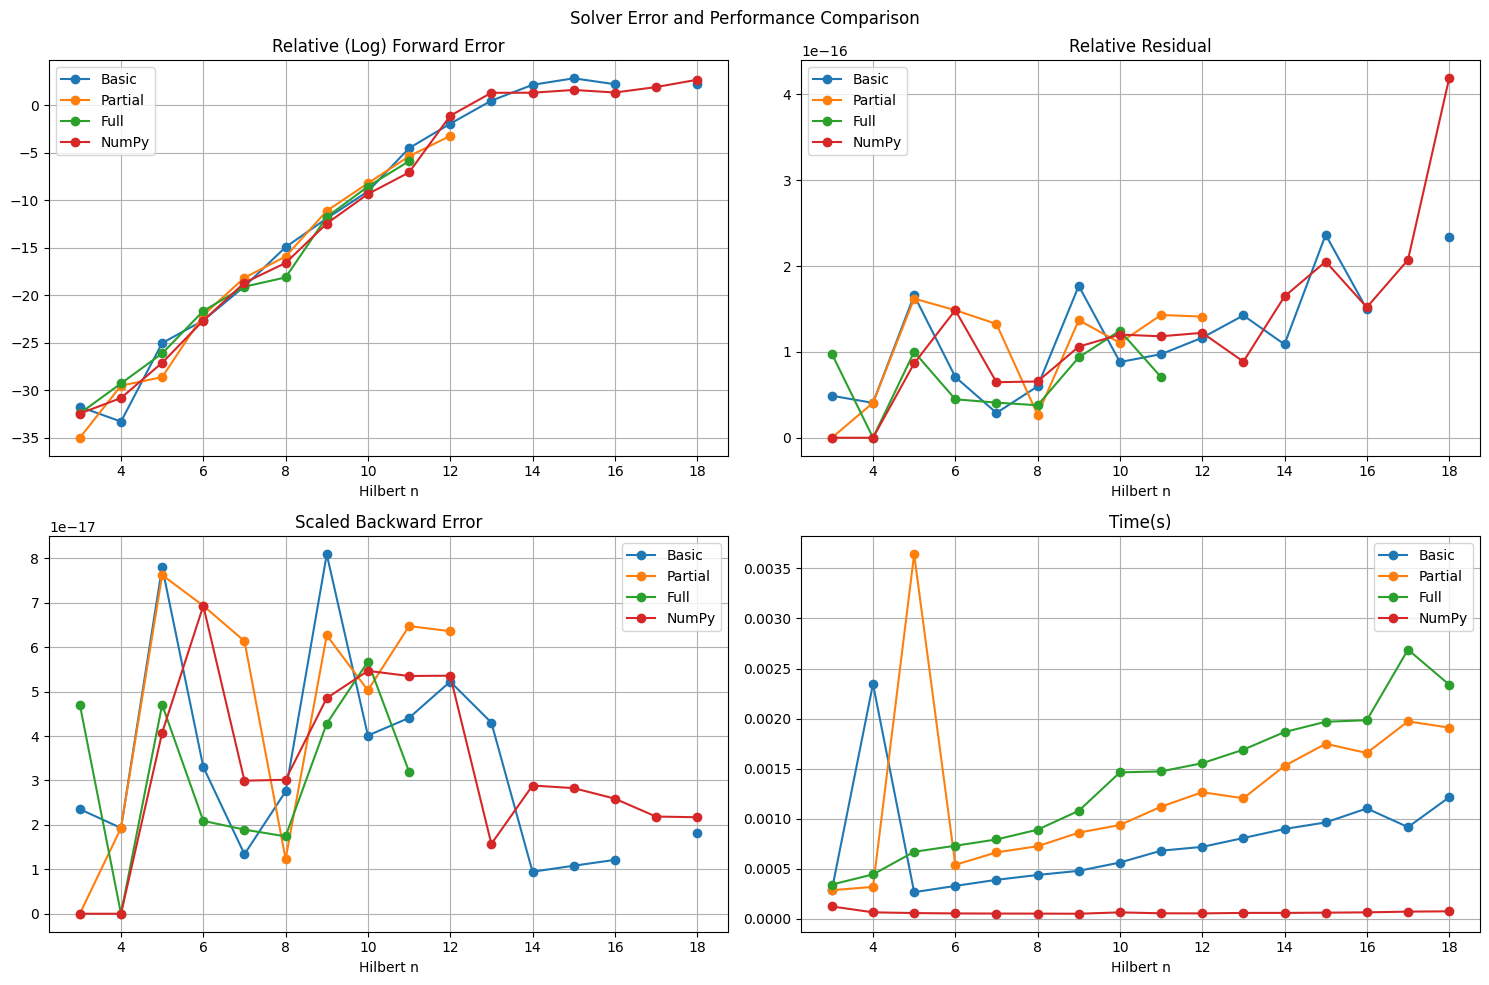


Saved results to lu_extended_results.csv


In [4]:
if __name__ == "__main__":

    #Set seed and Hilbert range
    rng = np.random.default_rng(1776)
    hn_l, hn_u = 3, 19
    results = []

    #Iterate through H_3...H_19
    for n in list(range(hn_l, hn_u)):

        #Generate H_n, solve Ax=b for A=H_n, x=1_n, b=H_n @ 1n (row sum)
        A = hilbert(n)
        x_true = np.ones(n)
        b = A @ x_true

        #Iterate through methods
        for meth,label in [("basic","Basic"),("partial","Partial"),("full","Full"),("numpy","NumPy")]:

            #Test solver
            row = errors_and_stats(A, x_true, method=meth)
            row["n"] = n
            row["label"] = label
            results.append(row)

    #Store results as dataframe
    print("Hilbert family:")
    df_h = pd.DataFrame(results)
    display(df_h.head(10))

    #Plot errors and time against H_n size
    fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(15,10))

    #Subset results DF by method.
    for meth,label in [("basic","Basic"),("partial","Partial"),("full","Full"),("numpy","NumPy")]:

        #Sort DF by H_n size
        y = df_h[df_h["method"]==meth].sort_values("n")

        #Plot 1: relative forward error (log scaled)
        axs[0][0].plot(y["n"], np.log(y["rel_forward_err"]), marker='o', label=label)

        #Plot 2: relative residual size
        axs[0][1].plot(y["n"], y["rel_residual"], marker='o', label=label)

        #Plot 3: scaled backward error
        axs[1][0].plot(y["n"], y["scaled_backward_err"], marker='o', label=label)

        #Plot 4: time
        axs[1][1].plot(y["n"], y["time_s"], marker='o', label=label)

    #Set subtitles individually
    axs[0][0].set_title("Relative (Log) Forward Error")
    axs[0][1].set_title("Relative Residual")
    axs[1][0].set_title("Scaled Backward Error")
    axs[1][1].set_title("Time(s)")

    #Plot niceties
    for ax in axs.flat:
      ax.grid(True); ax.legend()
      ax.set_xlabel("Hilbert n")

    #Display
    plt.suptitle("Solver Error and Performance Comparison")
    plt.tight_layout(); plt.show()

    #Write results to CSV, use CWD
    out_csv = "lu_extended_results.csv"
    df_h.to_csv(out_csv, index=False)
    print(f"\nSaved results to {out_csv}")

As expected, full pivoting generally produces the lowest errors, indicating greater numerical stability, but at the highest computational cost. Partial pivoting achieves much of the performance. Numpy's LU factorization is noticeably quicker and its time scaling is invariant to $H_{n}$'s size. My custom implementations fail for large $n$. Basic LU factorization is feasible for all but the largest $n$, whereas full and partial pivoting fails with more modest $n$.

In [5]:
df_h[df_h.status!="ok"].sort_values(by=["method","n"], ascending=[True,True])[["label","n","status"]].T

,56,38,42,46,50,54,58,62,41,45,49,53,57,61
label,Basic,Full,Full,Full,Full,Full,Full,Full,Partial,Partial,Partial,Partial,Partial,Partial
n,17,12,13,14,15,16,17,18,13,14,15,16,17,18
status,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError,fail: LinAlgError
